# Brazilian E-Commerce: Data Understanding & Initial Profiling
**Dataset**: Olist Brazilian E-Commerce Public Dataset  
**Objective**: Ingest all 9 raw tables, inspect schema structures, row/column counts, missingness, and verify relational keys.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

raw_dir = r'../data/raw'
files = [f for f in os.listdir(raw_dir) if f.endswith('.csv')]
print('Found files:', len(files))

summary = []
for f in files:
    path = os.path.join(raw_dir, f)
    df = pd.read_csv(path, nrows=1000)
    full_rows = sum(1 for _ in open(path, encoding='utf-8', errors='ignore')) - 1
    summary.append({
        'File': f,
        'Rows': full_rows,
        'Cols': len(df.columns),
        'Columns': ', '.join(df.columns[:4]) + ('...' if len(df.columns) > 4 else '')
    })
pd.DataFrame(summary)

Found files: 9


,File,Rows,Cols,Columns
0,olist_customers_dataset.csv,99441,5,"customer_id, customer_unique_id, customer_zip_..."
1,olist_geolocation_dataset.csv,1000163,5,"geolocation_zip_code_prefix, geolocation_lat, ..."
2,olist_orders_dataset.csv,99441,8,"order_id, customer_id, order_status, order_pur..."
3,olist_order_items_dataset.csv,112650,7,"order_id, order_item_id, product_id, seller_id..."
4,olist_order_payments_dataset.csv,103886,5,"order_id, payment_sequential, payment_type, pa..."
5,olist_order_reviews_dataset.csv,104719,7,"review_id, order_id, review_score, review_comm..."
6,olist_products_dataset.csv,32951,9,"product_id, product_category_name, product_nam..."
7,olist_sellers_dataset.csv,3095,4,"seller_id, seller_zip_code_prefix, seller_city..."
8,product_category_name_translation.csv,71,2,"product_category_name, product_category_name_e..."


In [2]:
orders = pd.read_csv(os.path.join(raw_dir, 'olist_orders_dataset.csv'))
items = pd.read_csv(os.path.join(raw_dir, 'olist_order_items_dataset.csv'))
payments = pd.read_csv(os.path.join(raw_dir, 'olist_order_payments_dataset.csv'))
customers = pd.read_csv(os.path.join(raw_dir, 'olist_customers_dataset.csv'))
reviews = pd.read_csv(os.path.join(raw_dir, 'olist_order_reviews_dataset.csv'))

print('Total Orders:', len(orders))
print('Unique Customers (customer_unique_id):', customers['customer_unique_id'].nunique())
print('Total Items Sold:', len(items))
print('Total Payments:', len(payments))
print('Total Reviews:', len(reviews))

Total Orders: 99441
Unique Customers (customer_unique_id): 96096
Total Items Sold: 112650
Total Payments: 103886
Total Reviews: 99224


Orders Null Counts:
 order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64


C:\Users\Shubham Meena\AppData\Local\Temp\ipykernel_23988\3495291236.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=null_summary[null_summary > 0].index, y=null_summary[null_summary > 0].values, palette='Blues_r')


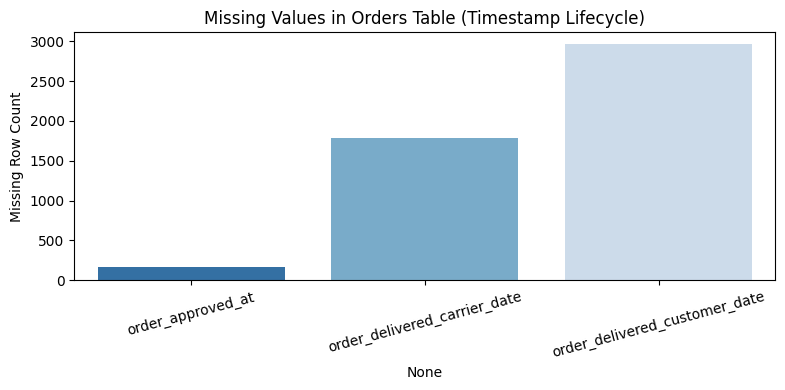

In [3]:
null_summary = orders.isna().sum()
print('Orders Null Counts:\n', null_summary[null_summary > 0])

plt.figure(figsize=(8, 4))
sns.barplot(x=null_summary[null_summary > 0].index, y=null_summary[null_summary > 0].values, palette='Blues_r')
plt.title('Missing Values in Orders Table (Timestamp Lifecycle)')
plt.ylabel('Missing Row Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()